# Análisis y Visualizaciones - Sistema Crunchyroll
Genera 5 gráficos desde la BD analítica (cru_olap) con respuestas a preguntas de negocio.

In [1]:
import sys
import io
import os
import psycopg2
from psycopg2.extras import RealDictCursor
import matplotlib
# matplotlib.use("Agg")  # Comentado para interactividad en Jupyter  # sin ventana, guarda como archivo
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker


# ─── Conexion ─────────────────────────────────────────────
DB_OLAP = {
    "host": os.getenv("DB_HOST", "localhost"),
    "database": "cru_olap",
    "user": os.getenv("DB_USER", "postgres"),
    "password": os.getenv("DB_PASSWORD", "martin2580"),
    "port": int(os.getenv("DB_PORT", "5432")),
}

# ─── Estilo general ───────────────────────────────────────
COLOR_FONDO   = "#0D1B2A"
COLOR_PANEL   = "#1A2B3C"
COLOR_TITULO  = "#FFFFFF"
COLOR_TEXTO   = "#CCCCCC"
COLOR_ACENTO  = "#F47521"   # naranja Crunchyroll
COLOR_AZUL    = "#3A86FF"
PALETA        = ["#F47521", "#3A86FF", "#06D6A0", "#FFD166",
                 "#EF476F", "#8338EC", "#FF70A6", "#70D6FF"]

plt.rcParams.update({
    "figure.facecolor":  COLOR_FONDO,
    "axes.facecolor":    COLOR_PANEL,
    "axes.edgecolor":    "#2A3B4C",
    "axes.labelcolor":   COLOR_TEXTO,
    "axes.titlecolor":   COLOR_TITULO,
    "xtick.color":       COLOR_TEXTO,
    "ytick.color":       COLOR_TEXTO,
    "text.color":        COLOR_TEXTO,
    "grid.color":        "#2A3B4C",
    "grid.linestyle":    "--",
    "grid.alpha":        0.5,
    "font.family":       "DejaVu Sans",
})

CARPETA = "graficos"
os.makedirs(CARPETA, exist_ok=True)


def consultar(sql):
    conn = psycopg2.connect(**DB_OLAP)
    cur = conn.cursor(cursor_factory=RealDictCursor)
    cur.execute(sql)
    filas = cur.fetchall()
    cur.close()
    conn.close()
    return filas


def guardar(fig, nombre):
    ruta = os.path.join(CARPETA, nombre)
    fig.savefig(ruta, dpi=150, bbox_inches="tight",
                facecolor=COLOR_FONDO)
    print(f"  Guardado: {ruta}")
    plt.show()  # Muestra el grafico en el notebook
    plt.close(fig)

In [2]:
# ─────────────────────────────────────────────────────────
# PREGUNTA 1: Top 10 contenidos mas vistos
# ─────────────────────────────────────────────────────────
def grafico_top10_contenidos():
    print("\n[1/5] Top 10 contenidos mas vistos...")
    sql = """
        SELECT
            dc.nombre,
            dc.tipo_contenido,
            COUNT(*) AS total_visualizaciones
        FROM fact_visualizaciones fv
        JOIN dim_contenido dc ON dc.id_dim_contenido = fv.id_dim_contenido
        GROUP BY dc.nombre, dc.tipo_contenido
        ORDER BY total_visualizaciones DESC
        LIMIT 10;
    """
    datos = consultar(sql)
    nombres  = [d["nombre"][:28] + "..." if len(d["nombre"]) > 28
                else d["nombre"] for d in datos]
    valores  = [d["total_visualizaciones"] for d in datos]
    colores  = [COLOR_ACENTO if d["tipo_contenido"] == "pelicula"
                else COLOR_AZUL for d in datos]

    fig, ax = plt.subplots(figsize=(12, 6))
    bars = ax.barh(nombres[::-1], valores[::-1], color=colores[::-1],
                   edgecolor="#0D1B2A", linewidth=0.5)

    for bar, val in zip(bars, valores[::-1]):
        ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height() / 2,
                f"{val:,}", va="center", fontsize=9, color=COLOR_TEXTO)

    ax.set_title("Top 10 Contenidos Mas Vistos", fontsize=15,
                 fontweight="bold", pad=15)
    ax.set_xlabel("Total de Visualizaciones")
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(
        lambda x, _: f"{int(x):,}"))
    ax.grid(axis="x")

    # Leyenda
    from matplotlib.patches import Patch
    leyenda = [Patch(color=COLOR_ACENTO, label="Pelicula"),
               Patch(color=COLOR_AZUL,   label="Serie")]
    ax.legend(handles=leyenda, loc="lower right",
              facecolor=COLOR_PANEL, edgecolor="#2A3B4C",
              labelcolor=COLOR_TEXTO)

    fig.tight_layout()
    guardar(fig, "1_top10_contenidos.png")

In [3]:
# ─────────────────────────────────────────────────────────
# PREGUNTA 2: Ingresos totales por plan de suscripcion
# ─────────────────────────────────────────────────────────
def grafico_ingresos_por_plan():
    print("\n[2/5] Ingresos por plan de suscripcion...")
    sql = """
        SELECT
            du.plan_nombre,
            du.plan_tipo,
            SUM(fp.monto) AS ingresos_totales,
            COUNT(*)      AS cantidad_pagos
        FROM fact_pagos fp
        JOIN dim_usuario du ON du.id_dim_usuario = fp.id_dim_usuario
        GROUP BY du.plan_nombre, du.plan_tipo
        ORDER BY ingresos_totales DESC;
    """
    datos = consultar(sql)
    etiquetas = [f"{d['plan_nombre']}\n({d['plan_tipo']})" for d in datos]
    valores   = [float(d["ingresos_totales"]) for d in datos]

    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.bar(etiquetas, valores, color=PALETA[:len(datos)],
                  edgecolor="#0D1B2A", linewidth=0.5, width=0.6)

    for bar, val in zip(bars, valores):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max(valores) * 0.01,
                f"${val:,.0f}", ha="center", fontsize=9,
                color=COLOR_TEXTO, fontweight="bold")

    ax.set_title("Ingresos Totales por Plan de Suscripcion",
                 fontsize=15, fontweight="bold", pad=15)
    ax.set_ylabel("Ingresos (CLP)")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(
        lambda x, _: f"${int(x):,}"))
    ax.grid(axis="y")
    fig.tight_layout()
    guardar(fig, "2_ingresos_por_plan.png")

In [4]:
# ─────────────────────────────────────────────────────────
# PREGUNTA 3: Generos mas populares segun visualizaciones
# ─────────────────────────────────────────────────────────
def grafico_generos_populares():
    print("\n[3/5] Generos mas populares...")
    sql = """
        SELECT
            TRIM(genero) AS genero,
            COUNT(*)     AS visualizaciones
        FROM fact_visualizaciones fv
        JOIN dim_contenido dc ON dc.id_dim_contenido = fv.id_dim_contenido,
        LATERAL UNNEST(STRING_TO_ARRAY(dc.generos, ',')) AS genero
        WHERE dc.generos <> 'Sin genero'
        GROUP BY TRIM(genero)
        ORDER BY visualizaciones DESC
        LIMIT 8;
    """
    datos = consultar(sql)
    generos = [d["genero"] for d in datos]
    valores = [d["visualizaciones"] for d in datos]

    fig, ax = plt.subplots(figsize=(8, 8))
    wedges, texts, autotexts = ax.pie(
        valores,
        labels=None,
        colors=PALETA[:len(datos)],
        autopct="%1.1f%%",
        startangle=140,
        wedgeprops={"edgecolor": COLOR_FONDO, "linewidth": 2},
        pctdistance=0.82,
    )
    for at in autotexts:
        at.set_color(COLOR_FONDO)
        at.set_fontsize(9)
        at.set_fontweight("bold")

    ax.legend(wedges, generos, title="Generos",
              loc="lower center", bbox_to_anchor=(0.5, -0.12),
              ncol=2, facecolor=COLOR_PANEL, edgecolor="#2A3B4C",
              labelcolor=COLOR_TEXTO, title_fontsize=10)

    ax.set_title("Generos Mas Populares por Visualizaciones",
                 fontsize=14, fontweight="bold", pad=20)
    fig.tight_layout()
    guardar(fig, "3_generos_populares.png")

In [5]:
# ─────────────────────────────────────────────────────────
# PREGUNTA 4: Usuarios por region
# ─────────────────────────────────────────────────────────
def grafico_usuarios_por_region():
    print("\n[4/5] Usuarios por region...")
    sql = """
        SELECT
            region,
            COUNT(*) AS total_usuarios
        FROM dim_usuario
        GROUP BY region
        ORDER BY total_usuarios DESC
        LIMIT 5;
    """
    datos = consultar(sql)
    regiones = [d["region"] for d in datos]
    valores  = [d["total_usuarios"] for d in datos]

    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.bar(regiones, valores, color=PALETA[:len(datos)],
                  edgecolor="#0D1B2A", linewidth=0.5, width=0.6)

    for bar, val in zip(bars, valores):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max(valores) * 0.01,
                f"{val:,}", ha="center", fontsize=10,
                color=COLOR_TEXTO, fontweight="bold")

    ax.set_title("Top 5 Regiones con Mas Usuarios",
                 fontsize=15, fontweight="bold", pad=15)
    ax.set_ylabel("Cantidad de Usuarios")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(
        lambda x, _: f"{int(x):,}"))
    ax.grid(axis="y", alpha=0.3)

    fig.tight_layout()
    guardar(fig, "4_usuarios_por_region.png")

In [6]:
# ─────────────────────────────────────────────────────────
# PREGUNTA 5: Porcentaje de contenido completado
# ─────────────────────────────────────────────────────────
def grafico_completado_por_tipo():
    print("\n[5/5] Completado promedio por tipo de contenido...")
    sql = """
        SELECT
            dc.tipo_contenido,
            ROUND(AVG(fv.porcentaje_completado), 2) AS promedio_completado,
            COUNT(*) FILTER (WHERE fv.visualizacion_completa = TRUE) AS completas,
            COUNT(*)                                                   AS total
        FROM fact_visualizaciones fv
        JOIN dim_contenido dc ON dc.id_dim_contenido = fv.id_dim_contenido
        GROUP BY dc.tipo_contenido;
    """
    datos = consultar(sql)

    tipos     = [d["tipo_contenido"].capitalize() for d in datos]
    promedio  = [float(d["promedio_completado"]) for d in datos]
    pct_comp  = [round(d["completas"] / d["total"] * 100, 1) for d in datos]

    x = range(len(tipos))
    ancho = 0.35

    fig, ax = plt.subplots(figsize=(9, 6))
    b1 = ax.bar([i - ancho/2 for i in x], promedio,
                width=ancho, label="% Promedio visto",
                color=COLOR_ACENTO, edgecolor="#0D1B2A")
    b2 = ax.bar([i + ancho/2 for i in x], pct_comp,
                width=ancho, label="% Visto completo (>=90%)",
                color=COLOR_AZUL, edgecolor="#0D1B2A")

    for bar, val in zip(list(b1) + list(b2),
                        promedio + pct_comp):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.5,
                f"{val}%", ha="center", fontsize=10,
                color=COLOR_TEXTO, fontweight="bold")

    ax.set_xticks(list(x))
    ax.set_xticklabels(tipos, fontsize=12)
    ax.set_title("Completitud de Visualizacion por Tipo de Contenido",
                 fontsize=14, fontweight="bold", pad=15)
    ax.set_ylabel("Porcentaje (%)")
    ax.set_ylim(0, 115)
    ax.legend(facecolor=COLOR_PANEL, edgecolor="#2A3B4C",
              labelcolor=COLOR_TEXTO)
    ax.grid(axis="y")
    fig.tight_layout()
    guardar(fig, "5_completado_por_tipo.png")

  ANALISIS Y VISUALIZACIONES - Crunchyroll OLAP

[1/5] Top 10 contenidos mas vistos...


  Guardado: graficos\1_top10_contenidos.png


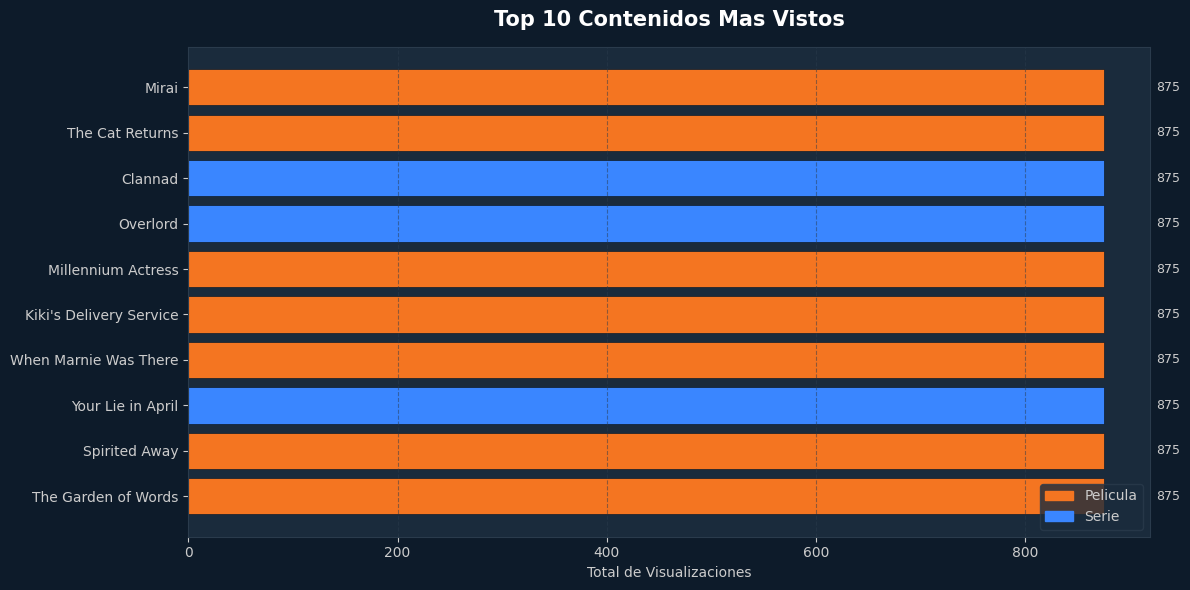


[2/5] Ingresos por plan de suscripcion...


  Guardado: graficos\2_ingresos_por_plan.png


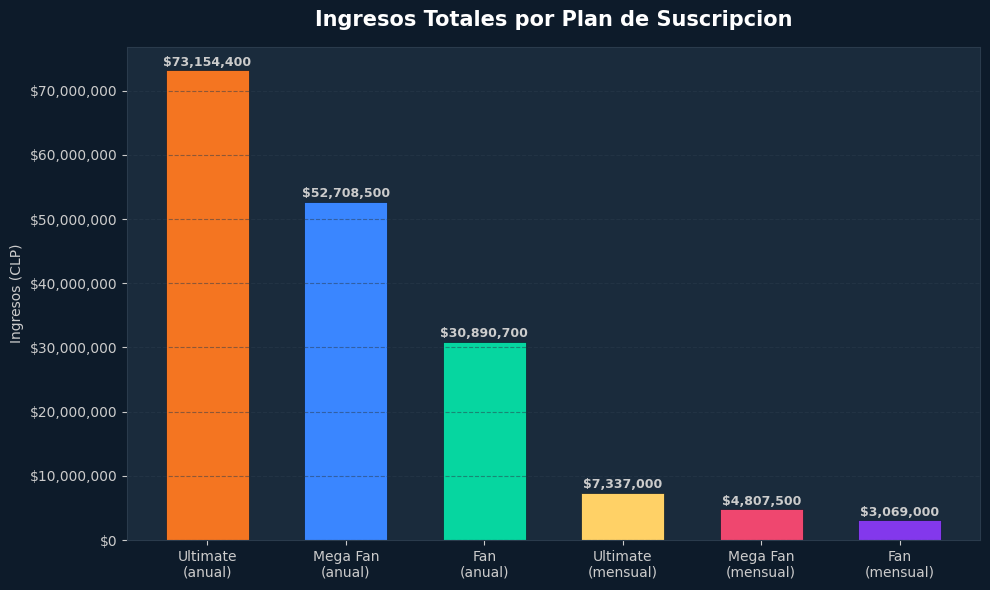


[3/5] Generos mas populares...


  Guardado: graficos\3_generos_populares.png


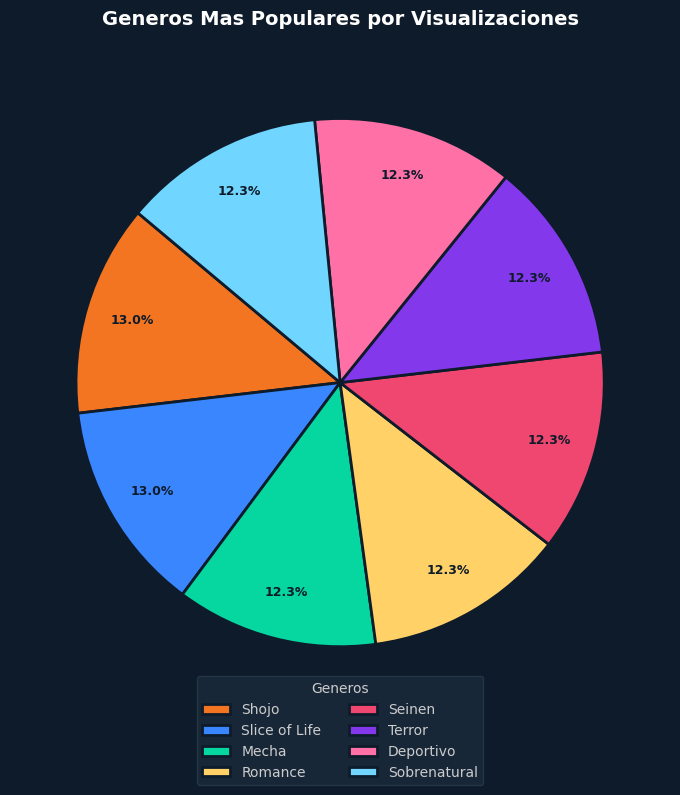


[4/5] Usuarios por region...


  Guardado: graficos\4_usuarios_por_region.png


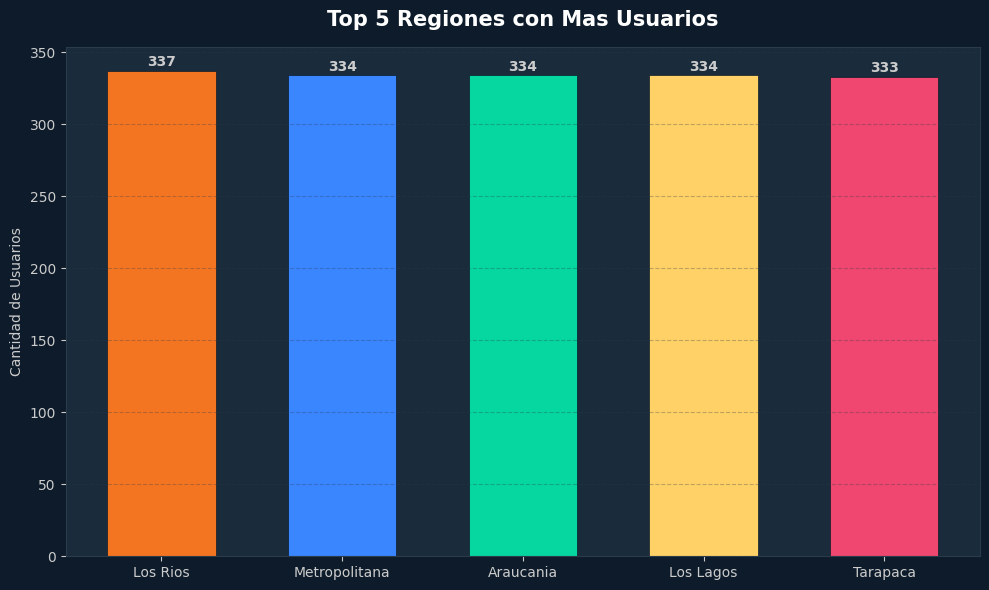


[5/5] Completado promedio por tipo de contenido...


  Guardado: graficos\5_completado_por_tipo.png


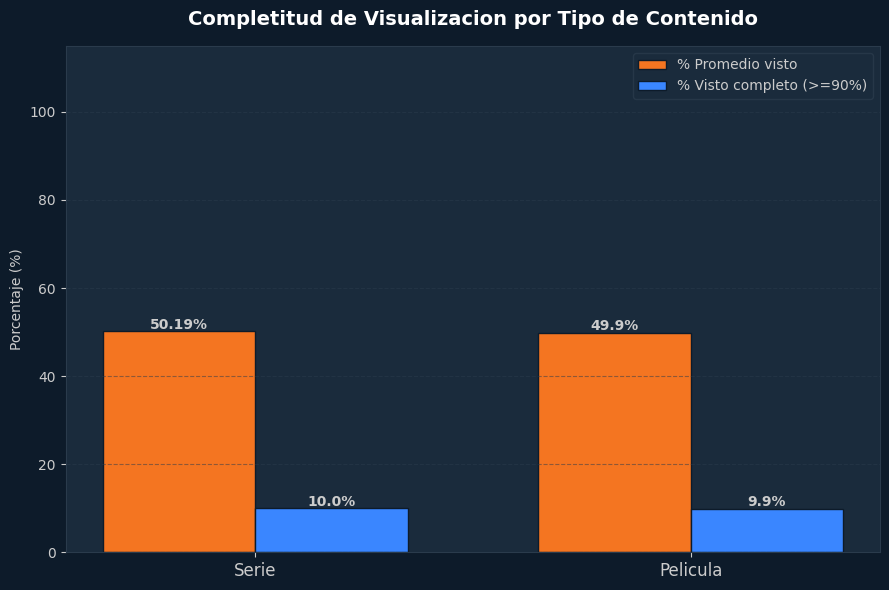


  5 graficos guardados en la carpeta 'graficos/'


In [7]:
# ─── MAIN ─────────────────────────────────────────────────
if __name__ == "__main__":
    print("=" * 55)
    print("  ANALISIS Y VISUALIZACIONES - Crunchyroll OLAP")
    print("=" * 55)

    grafico_top10_contenidos()
    grafico_ingresos_por_plan()
    grafico_generos_populares()
    grafico_usuarios_por_region()
    grafico_completado_por_tipo()

    print()
    print("=" * 55)
    print(f"  5 graficos guardados en la carpeta '{CARPETA}/'")
    print("=" * 55)